# Import Libraries

In [1]:
# Standard libraries
import os  # OS operations
import shutil  # File operations

# Data handling
import pandas as pd  # DataFrames
import numpy as np  # Numerical ops

# Visualization
import matplotlib.pyplot as plt  # Plots
import seaborn as sns  # Statistical plots

# KaggleHub for downloading datasets/models
import kagglehub

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Computer vision
import cv2  # Image processing

# Scikit-learn utilities and metrics
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import EfficientNetB7
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

2025-08-23 19:13:57.695540: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755976437.929025      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755976437.994997      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load Dataset

In [2]:
train_dir = '/kaggle/input/OCT2017 /train'
test_dir = '/kaggle/input/OCT2017 /test'
validation_dir = '/kaggle/input/OCT2017 /val'

# Image counts in directory

In [3]:
# Function to count images in each directory
def count_images_in_dirs(base_dir):
    dir_counts = {}
    for root, _, files in os.walk(base_dir):
        # Filter out non-image files if necessary, here we assume all are images
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
        if image_files: # Only add directory if it contains images
            dir_counts[root] = len(image_files)
    return dir_counts

# Check image counts in train, validation, and test directories
print("Image counts in Train Directory:")
train_counts = count_images_in_dirs(train_dir)
for directory, count in train_counts.items():
    print(f"  {directory}: {count} images")

print("\nImage counts in Validation Directory:")
validation_counts = count_images_in_dirs(validation_dir)
for directory, count in validation_counts.items():
    print(f"  {directory}: {count} images")

print("\nImage counts in Test Directory:")
test_counts = count_images_in_dirs(test_dir)
for directory, count in test_counts.items():
    print(f"  {directory}: {count} images")

# Optional: Print total counts per split
total_train = sum(train_counts.values())
total_validation = sum(validation_counts.values())
total_test = sum(test_counts.values())

print(f"\nTotal images in train set: {total_train}")
print(f"Total images in validation set: {total_validation}")
print(f"Total images in test set: {total_test}")

Image counts in Train Directory:
  /kaggle/input/OCT2017 /train/DRUSEN: 8616 images
  /kaggle/input/OCT2017 /train/CNV: 37205 images
  /kaggle/input/OCT2017 /train/NORMAL: 26315 images
  /kaggle/input/OCT2017 /train/DME: 11348 images

Image counts in Validation Directory:
  /kaggle/input/OCT2017 /val/DRUSEN: 8 images
  /kaggle/input/OCT2017 /val/CNV: 8 images
  /kaggle/input/OCT2017 /val/NORMAL: 8 images
  /kaggle/input/OCT2017 /val/DME: 8 images

Image counts in Test Directory:
  /kaggle/input/OCT2017 /test/DRUSEN: 242 images
  /kaggle/input/OCT2017 /test/CNV: 242 images
  /kaggle/input/OCT2017 /test/NORMAL: 242 images
  /kaggle/input/OCT2017 /test/DME: 242 images

Total images in train set: 83484
Total images in validation set: 32
Total images in test set: 968


# Distribution of Images per Class and Set

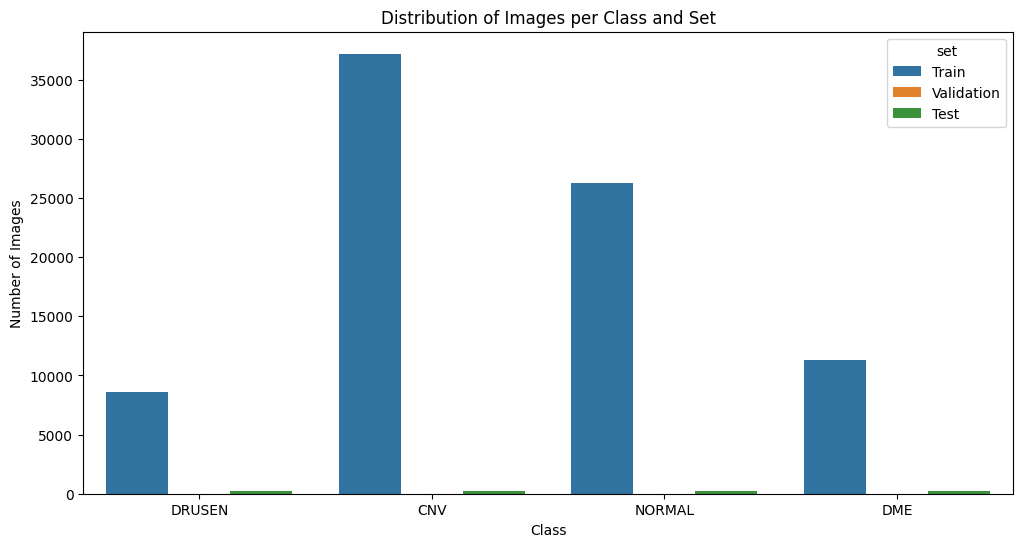

In [4]:
# Create DataFrames from the counts for easier plotting
train_df = pd.DataFrame.from_dict(train_counts, orient='index', columns=['count'])
train_df['set'] = 'Train'
train_df['class'] = train_df.index.str.split('/').str[-1] # Extract class name from path

validation_df = pd.DataFrame.from_dict(validation_counts, orient='index', columns=['count'])
validation_df['set'] = 'Validation'
validation_df['class'] = validation_df.index.str.split('/').str[-1] # Extract class name from path

test_df = pd.DataFrame.from_dict(test_counts, orient='index', columns=['count'])
test_df['set'] = 'Test'
test_df['class'] = test_df.index.str.split('/').str[-1] # Extract class name from path

# Combine the DataFrames
combined_df = pd.concat([train_df, validation_df, test_df])

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='class', y='count', hue='set', data=combined_df)
plt.title('Distribution of Images per Class and Set')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()

# Display sample images

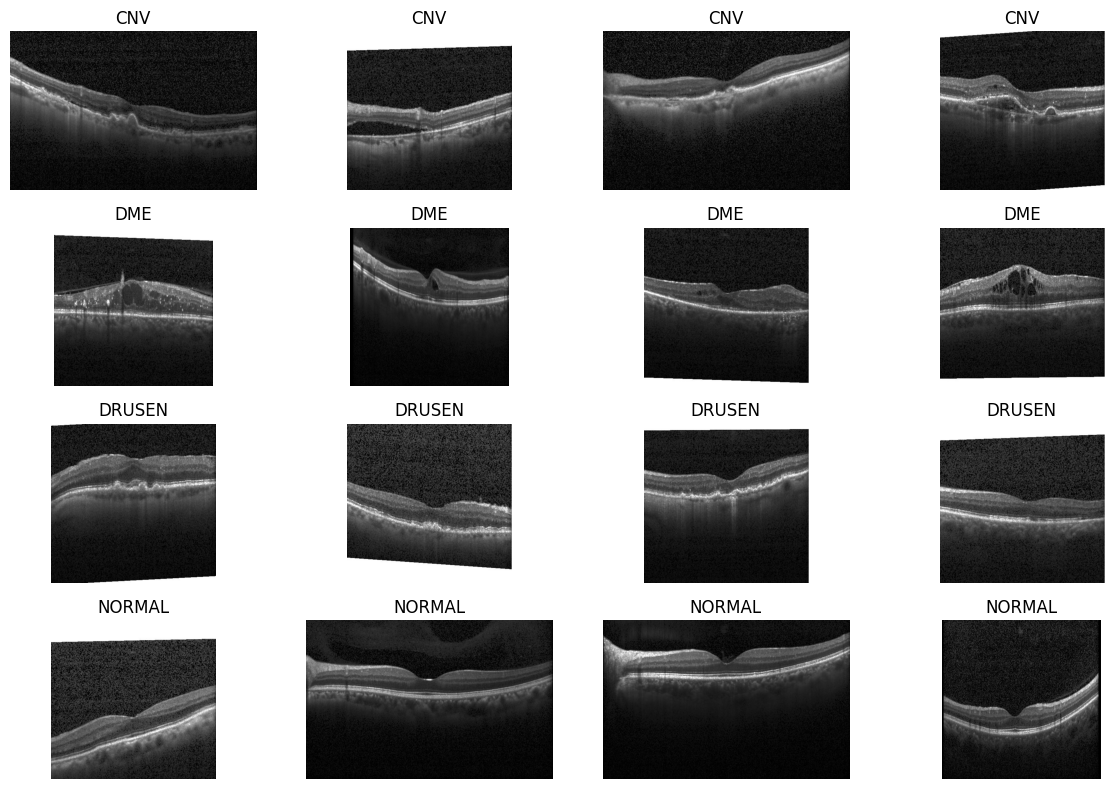

In [5]:
# Categories from your dataset
categories = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

# Function to display sample images
def display_sample_images(directory, num_images=4):
    plt.figure(figsize=(12, 8))
    i = 0
    for category in categories:
        category_path = os.path.join(directory, category)
        image_files = [f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))][:num_images] # Take up to num_images

        for img_file in image_files:
            img_path = os.path.join(category_path, img_file)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

            plt.subplot(len(categories), num_images, i + 1)
            plt.imshow(img)
            plt.title(f"{category}")
            plt.axis('off')
            i += 1
            if i >= len(categories) * num_images: # Stop if we have enough images
              break
        if i >= len(categories) * num_images: # Stop if we have enough images
          break

    plt.tight_layout()
    plt.show()

# Display sample images
display_sample_images(train_dir, num_images=4)

# Image Data Generator

In [6]:
# Image Data Generator
datagen = ImageDataGenerator(rescale=1./255)

# Create generators from the split directories
train_generator = datagen.flow_from_directory(
    train_dir,  # Use the training directory
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = datagen.flow_from_directory(
    validation_dir,  # Use the validation directory
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

test_generator = datagen.flow_from_directory(
    test_dir,  # Use the test directory
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Keep order for evaluation metrics
)

Found 83484 images belonging to 4 classes.
Found 32 images belonging to 4 classes.
Found 968 images belonging to 4 classes.


# EfficientNetB7 Pretrained Model

## Build Model

In [7]:
# Clear previous models
tf.keras.backend.clear_session()

# Load the EfficientNetB7 model
base_model = EfficientNetB7(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Add a custom head for the classification task
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(len(categories), activation='softmax')(x) # Use the number of categories

# Define the model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

I0000 00:00:1755976590.215251      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


 ## Callbacks

In [8]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

## Model Training

In [9]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[early_stopping],
)

Epoch 1/10


I0000 00:00:1755976789.244124      85 service.cc:148] XLA service 0x7b0434002260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755976789.245137      85 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1755976806.536471      85 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1755976827.528345      85 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755976827.725359      85 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755976828.068678      85 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755976828.2651

 592/2609 ━━━━━━━━━━━━━━━━━━━━ 9:14 275ms/step - accuracy: 0.7131 - loss: 0.8002

E0000 00:00:1755977087.064466      84 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755977087.262874      84 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755977087.612542      84 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755977087.811108      84 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755977088.211271      84 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

2609/2609 ━━━━━━━━━━━━━━━━━━━━ 1277s 379ms/step - accuracy: 0.8279 - loss: 0.4953 - val_accuracy: 1.0000 - val_loss: 0.1936
Epoch 2/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 719s 275ms/step - accuracy: 0.9471 - loss: 0.1675 - val_accuracy: 0.9688 - val_loss: 0.0521
Epoch 3/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 718s 275ms/step - accuracy: 0.9607 - loss: 0.1209 - val_accuracy: 0.9688 - val_loss: 0.2907
Epoch 4/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 718s 275ms/step - accuracy: 0.9696 - loss: 0.0950 - val_accuracy: 0.7812 - val_loss: 0.5862
Epoch 5/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 717s 275ms/step - accuracy: 0.9767 - loss: 0.0706 - val_accuracy: 0.8438 - val_loss: 0.3342
Epoch 6/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 716s 275ms/step - accuracy: 0.9816 - loss: 0.0558 - val_accuracy: 0.9375 - val_loss: 0.1514


## Model Evaluation

In [10]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(test_generator)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 505ms/step - accuracy: 0.9920 - loss: 0.0463
Test Accuracy: 99.07%
Test Loss: 0.0522


# Model Prediction and Testing

## Training and Validation

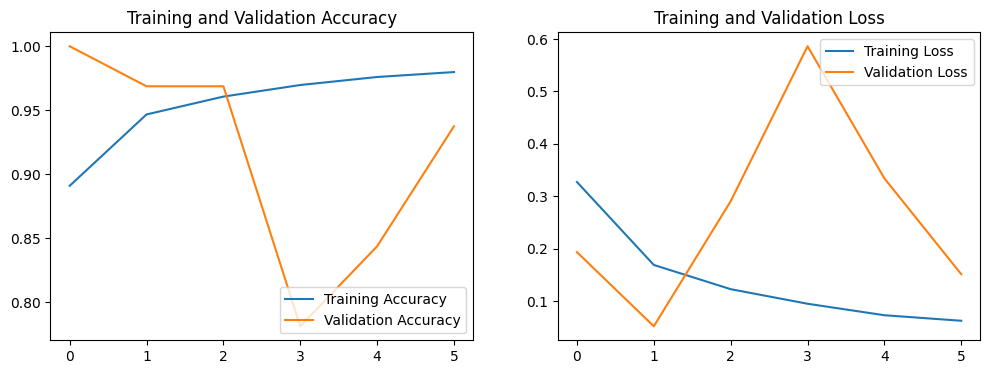

In [11]:
# Plot training and validation accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Classification Report

In [12]:
# Get predictions for the test set
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# Get the class labels
class_labels = list(test_generator.class_indices.keys())

# Generate and print the classification report
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print("\nClassification Report:")
print(report)

31/31 ━━━━━━━━━━━━━━━━━━━━ 38s 660ms/step

Classification Report:
              precision    recall  f1-score   support

         CNV       0.99      0.99      0.99       242
         DME       0.98      1.00      0.99       242
      DRUSEN       1.00      0.98      0.99       242
      NORMAL       0.99      1.00      0.99       242

    accuracy                           0.99       968
   macro avg       0.99      0.99      0.99       968
weighted avg       0.99      0.99      0.99       968



## Confusion Matrix

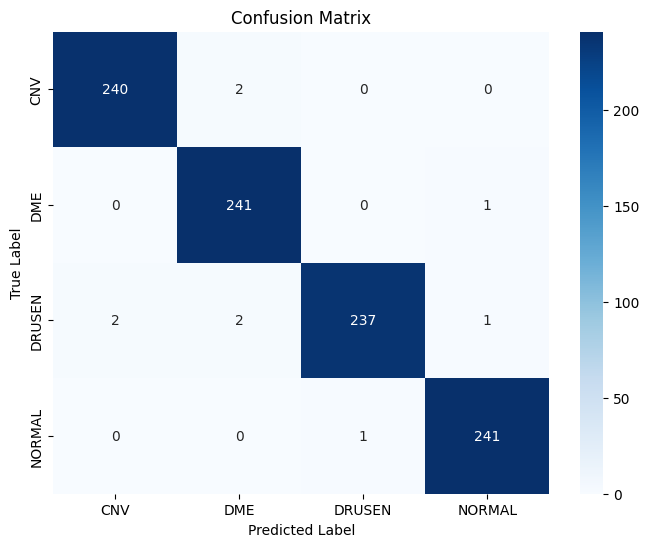

In [13]:
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## ROC Curve

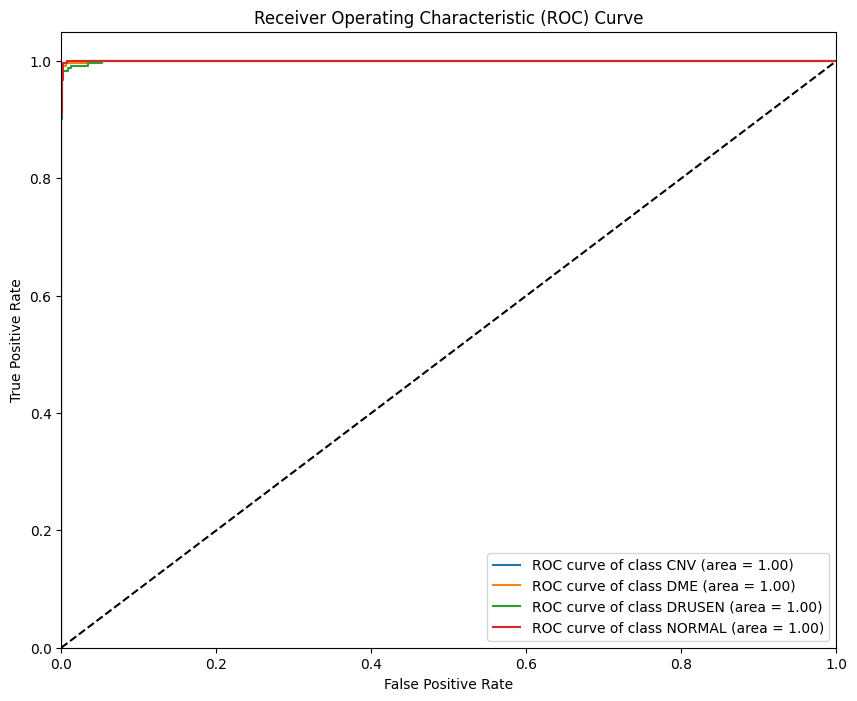

In [14]:
# Binarize the true labels for multi-class ROC
true_classes_binarized = label_binarize(true_classes, classes=np.unique(true_classes))

# Compute ROC curve and ROC AUC for each class
fpr = dict()
tpl = dict()
roc_auc = dict()
n_classes = len(class_labels)

for i in range(n_classes):
    fpr[i], tpl[i], _ = roc_curve(true_classes_binarized[:, i], predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpl[i])

# Plot the ROC curve
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpl[i], label=f'ROC curve of class {class_labels[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

## Precision-Recall Curve

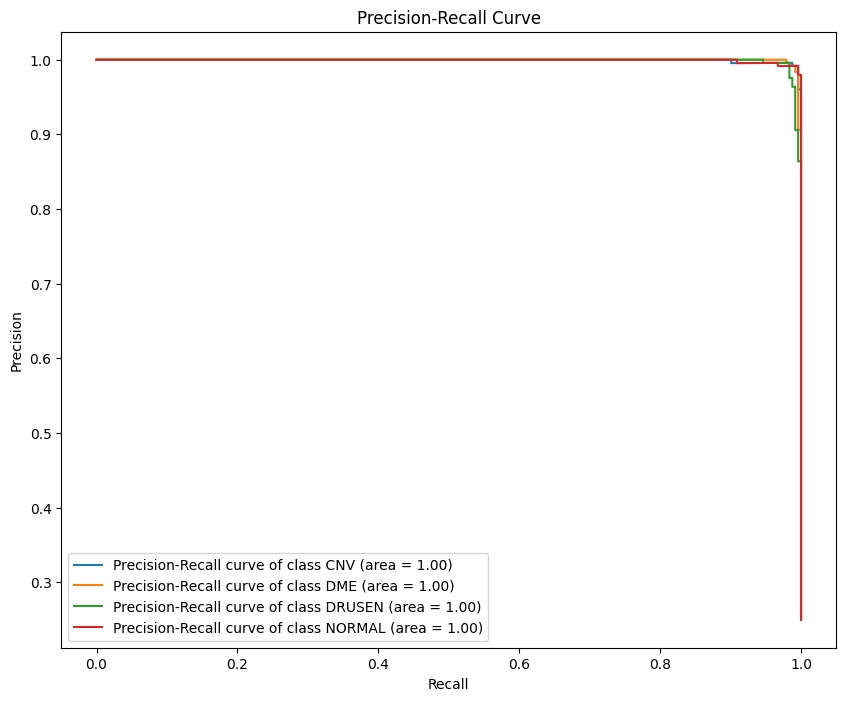

In [15]:
# Compute Precision-Recall curve and Average Precision for each class
precision = dict()
recall = dict()
average_precision = dict()
n_classes = len(class_labels)

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(true_classes_binarized[:, i], predictions[:, i])
    average_precision[i] = average_precision_score(true_classes_binarized[:, i], predictions[:, i])

# Plot the Precision-Recall curve
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(recall[i], precision[i], label=f'Precision-Recall curve of class {class_labels[i]} (area = {average_precision[i]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

## Testing on one image from each class


1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


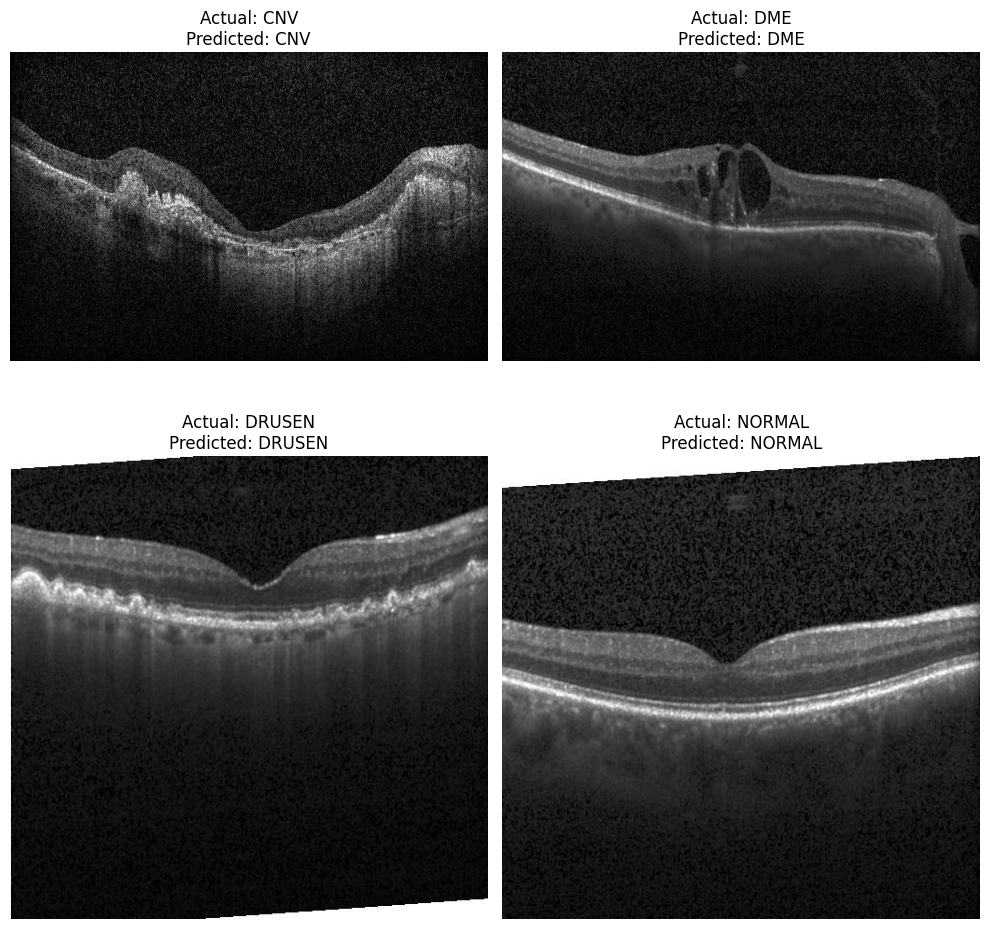

In [16]:
# Get a list of image paths for each class in the test set
test_image_paths = {}
for category in categories:
    category_path = os.path.join(test_dir, category)
    image_files = [f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))]
    if image_files:
        # Select one random image from each class
        test_image_paths[category] = os.path.join(category_path, np.random.choice(image_files))

# Display one image from each class and predict its label
plt.figure(figsize=(10, 10))
subplot_index = 1
for category, img_path in test_image_paths.items():
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_for_prediction = cv2.resize(img, (128, 128)) # Resize to model input size
    img_for_prediction = img_for_prediction / 255.0  # Rescale
    img_for_prediction = np.expand_dims(img_for_prediction, axis=0) # Add batch dimension

    # Get prediction
    prediction = model.predict(img_for_prediction)
    predicted_class_index = np.argmax(prediction)
    predicted_label = categories[predicted_class_index] # Use categories list for label

    plt.subplot(2, 2, subplot_index)
    plt.imshow(img)
    plt.title(f"Actual: {category}\nPredicted: {predicted_label}")
    plt.axis('off')
    subplot_index += 1

plt.tight_layout()
plt.show()

## Save Model

In [17]:
model.save(f'oct_disease_classification_model_acc_{accuracy * 100:.2f}%.keras')